# IV.POS.9 Track-B — coverage curves · **step-domain re-run campaign**

Per-guest coverage (N=5000, seed 1234), four variants. **Local Context (CTX)** and **CGC** are shown
side-by-side as the primary metrics; **Constraint Locations (LOC)** are in their own separate cells.
Every figure is also saved as a standalone PNG in `./pngs/`.

**Provenance (read `PROVENANCE.md`).** Two sources only, read read-only & in place, final-campaign only:
`stepdomain_rerun` (V6_uniform, V6_cTS, Hybrid_cTS — POS nodes, binary `53c21894` + python `68d90aa`) and
`3kind_rerun_external` (**V5_control / A3 Bandit** — coinbase `results_rerun`/`results_miss`; A4 is immune to
the step-domain bug). The original Jun-24 `data/` and the confounded 3-kind Arguzz arms are excluded.

In [1]:
import csv, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

BASE = "a4/runs/iv_pos_9/sweep/campaign_stepdomain_rerun/data_extracted"
PNGDIR = "a4/runs/iv_pos_9/sweep/campaign_stepdomain_rerun/pngs"
os.makedirs(PNGDIR, exist_ok=True)
N = 5000
VARIANTS = ["V5_control", "V6_uniform", "V6_cTS", "Hybrid_cTS"]
DISPLAY  = {"V5_control": "A3 Bandit", "V6_uniform": "Arguzz",
            "V6_cTS": "Arguzz Bandit", "Hybrid_cTS": "A3+Arguzz Bandit"}
COLORS   = {"V5_control": "#1f77b4", "V6_uniform": "#000000",   # Arguzz = black
            "V6_cTS": "#ff7f0e", "Hybrid_cTS": "#d62728"}
GUEST_TITLE = {"g0_baseline": "Product-program mixed arithmetic",
               "g1_ecall_control": "System-call / control-heavy guest",
               "g2_mem_stress": "Memory-stress guest",
               "g3_accelerator": "Accelerator/SHA guest"}
GUESTS = list(GUEST_TITLE.items())
METRICS = [("LOC", "Constraint Locations"), ("CTX", "Local Contexts"), ("CGC", "Compressed Global Contexts")]
SEEDS = ["1234", "1235", "1236"]

def savepng(fig, name):
    fig.savefig(f"{PNGDIR}/{name}.png", dpi=130, bbox_inches="tight")

jobs = list(csv.DictReader(open(f"{BASE}/jobs.csv"), delimiter="|"))
canon = {(j["guest"], j["variant"], j["seed"]): j["host"] for j in jobs}
points = {}
for r in csv.DictReader(open(f"{BASE}/curve_points.csv"), delimiter="|"):
    k = (r["guest"], r["variant"], r["seed"])
    if canon.get(k) != r["host"]:
        continue
    points.setdefault((*k, r["metric"]), []).append(int(r["first_hit_mutation_id"]))

KEYSETS = {}
for line in open(f"{BASE}/keys.csv"):
    line = line.rstrip("\n")
    p = line.split("|", 5)
    if len(p) != 6 or p[0] == "source":
        continue
    KEYSETS.setdefault((p[1], p[2], p[3], p[4]), set()).add(p[5])

def cum(ids):
    a = np.zeros(N + 1)
    for m in ids:
        if 1 <= m <= N:
            a[m] += 1
    return np.cumsum(a)

print(f"loaded {len(jobs)} jobs, {sum(len(v) for v in points.values())} curve points, {len(KEYSETS)} key-sets")

loaded 47 jobs, 45195 curve points, 141 key-sets


## Data inventory & provenance

In [2]:
print("AVAILABILITY (✓ present; s=stepdomain_rerun, x=3kind_external):")
print(f"{'guest · seed':<20}" + "".join(f"{DISPLAY[v][:15]:<17}" for v in VARIANTS))
tag = {"stepdomain_rerun": "s", "3kind_rerun_external": "x"}
have = {(j["guest"], j["variant"], j["seed"]): tag.get(j["source"], "?") for j in jobs}
for g, _ in GUESTS:
    for s in SEEDS:
        print(f"{g+' s'+s:<20}" + "".join(f"{('✓('+have[(g,v,s)]+')') if (g,v,s) in have else '·':<17}" for v in VARIANTS))
print("\nSOURCE MANIFEST:")
print(f"{'source':<22}{'guest':<17}{'variant':<12}{'seed':<6}{'ncamp':>6}{'n_mut':>7}  db_path")
for j in sorted(jobs, key=lambda r:(r['source'], r['guest'], r['variant'], r['seed'])):
    print(f"{j['source']:<22}{j['guest']:<17}{j['variant']:<12}{j['seed']:<6}{j['ncamp']:>6}{j['n_mut']:>7}  {j['db_path']}")

AVAILABILITY (✓ present; s=stepdomain_rerun, x=3kind_external):
guest · seed        A3 Bandit        Arguzz           Arguzz Bandit    A3+Arguzz Bandi  
g0_baseline s1234   ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g0_baseline s1235   ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g0_baseline s1236   ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g1_ecall_control s1234✓(x)             ✓(s)             ✓(s)             ✓(s)             
g1_ecall_control s1235✓(x)             ·                ✓(s)             ✓(s)             
g1_ecall_control s1236✓(x)             ✓(s)             ✓(s)             ✓(s)             
g2_mem_stress s1234 ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g2_mem_stress s1235 ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g2_mem_stress s1236 ✓(x)             ✓(s)             ✓(s)             ✓(s)             
g3_accelerator s1234✓(x)             ✓(s

## Coverage curves — Local Context + CGC
Cumulative distinct coverage vs mutation index (seed 1234). Local Context (left) and CGC (right). One figure
per guest; saved as `pngs/curves_ctxcgc_<guest>.png`.

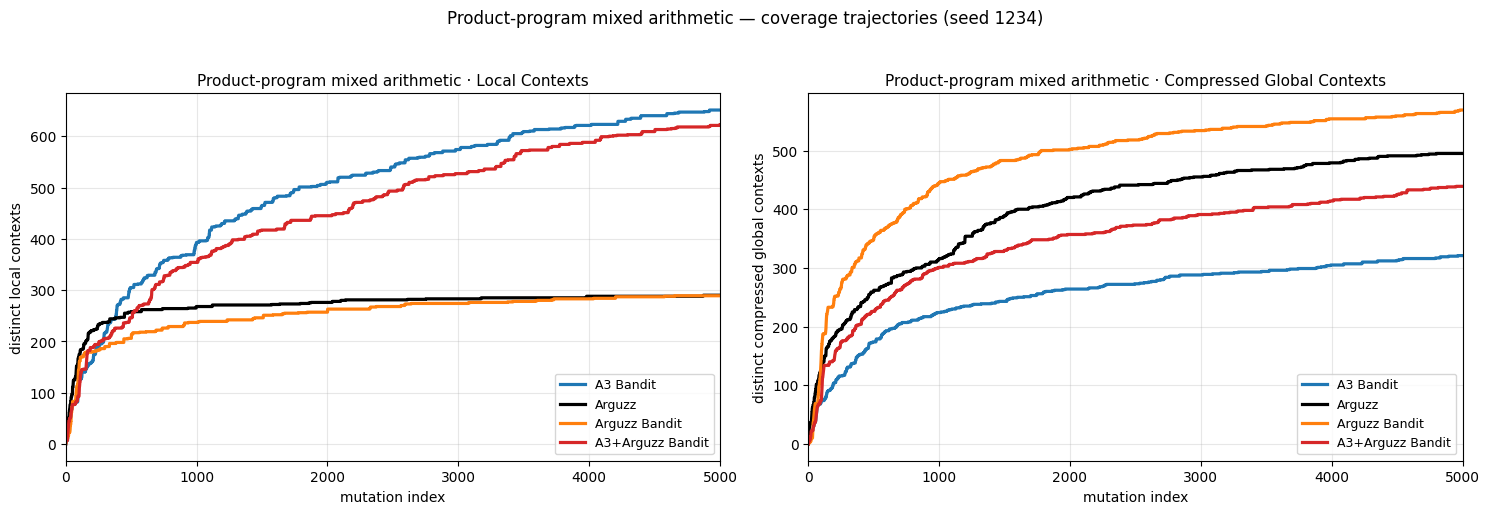

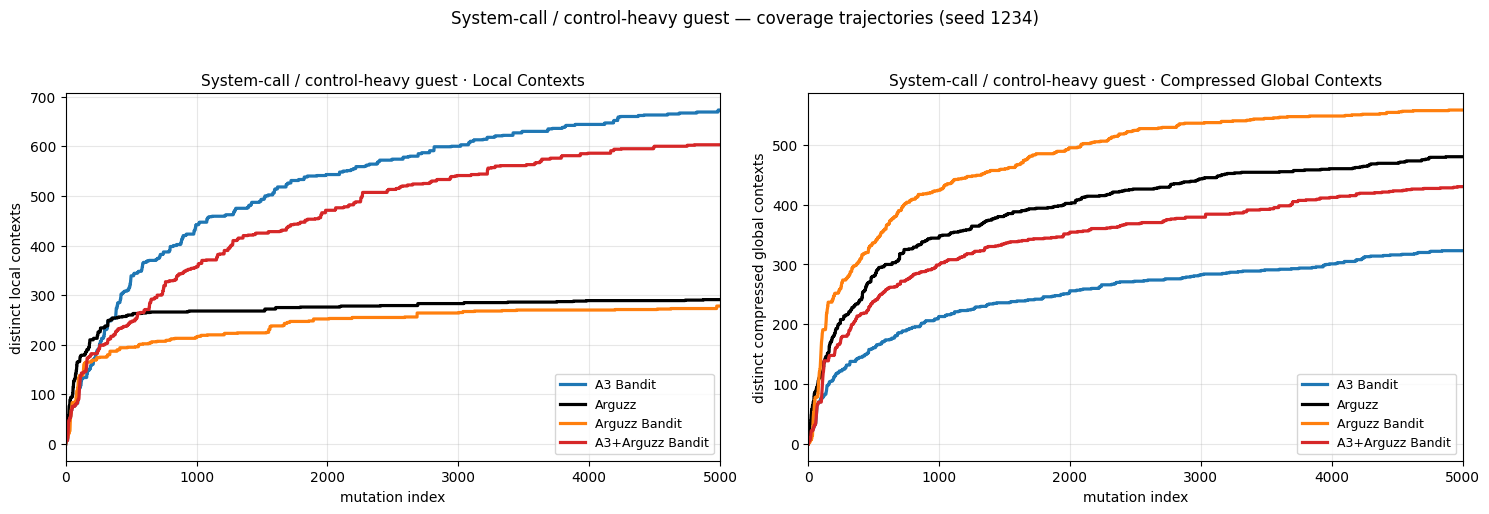

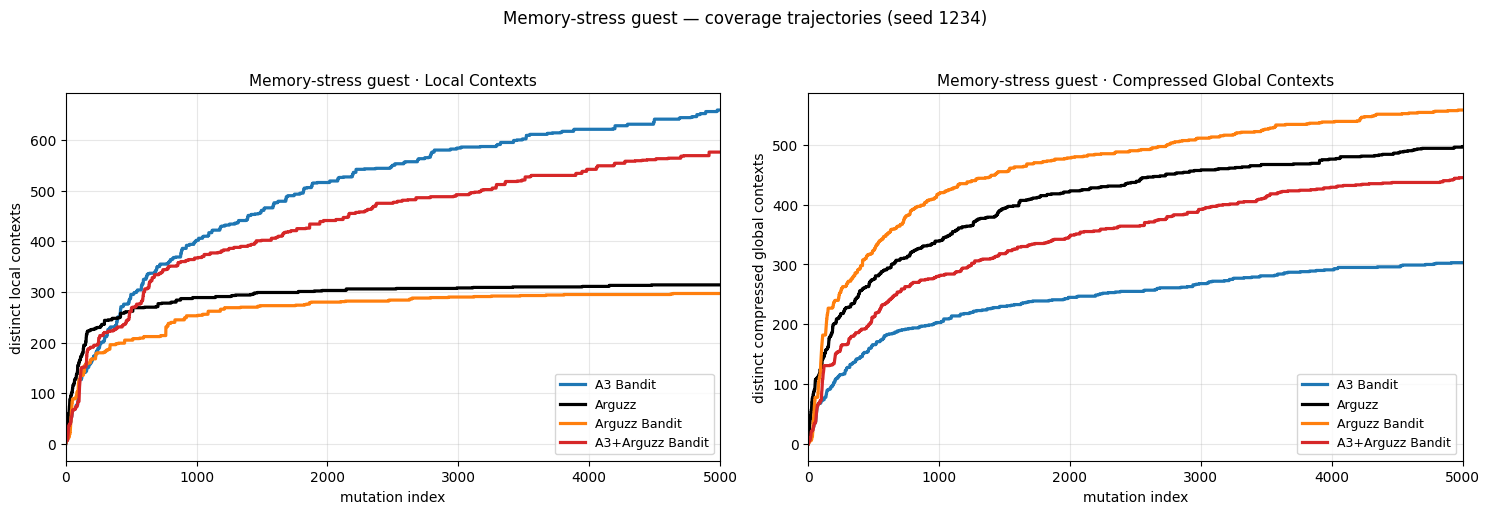

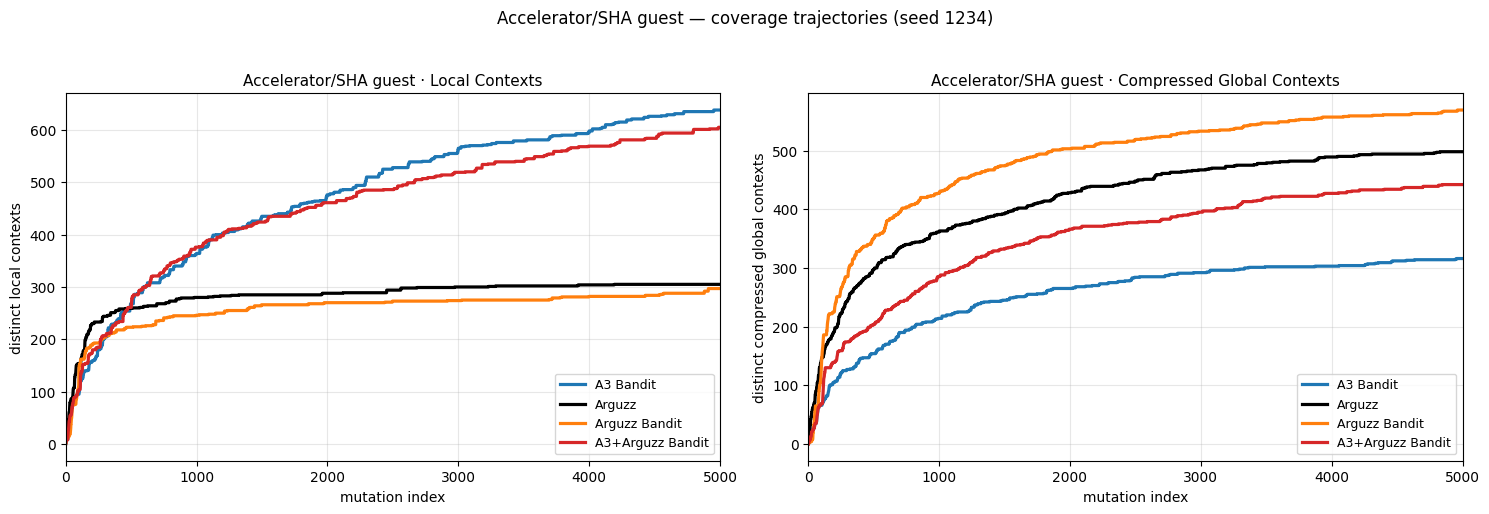

In [3]:
SEED = "1234"
for g, _ in GUESTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    for ax, (mk, ml) in zip(axes, [("CTX", "Local Contexts"), ("CGC", "Compressed Global Contexts")]):
        for v in VARIANTS:
            ids = points.get((g, v, SEED, mk))
            if ids is None:
                continue
            ax.plot(np.arange(N + 1), cum(ids), color=COLORS[v], lw=2.3, label=DISPLAY[v])
        ax.set_title(f"{GUEST_TITLE[g]} · {ml}", fontsize=11)
        ax.set_xlabel("mutation index"); ax.set_ylabel(f"distinct {ml.lower()}")
        ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3); ax.margins(x=0)
    fig.suptitle(f"{GUEST_TITLE[g]} — coverage trajectories (seed {SEED})", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95]); savepng(fig, f"curves_ctxcgc_{g}"); plt.show()

## Coverage curves — Constraint Locations (separate)
The LOC trajectories, pulled out on their own. Saved as `pngs/curves_loc_<guest>.png`.

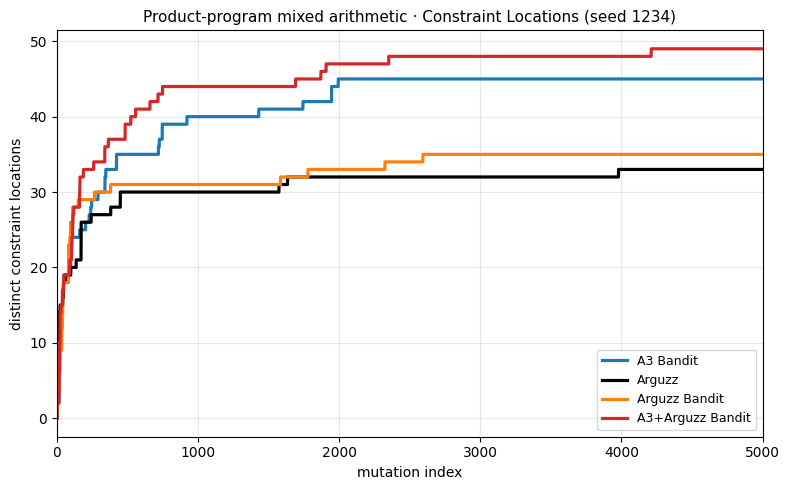

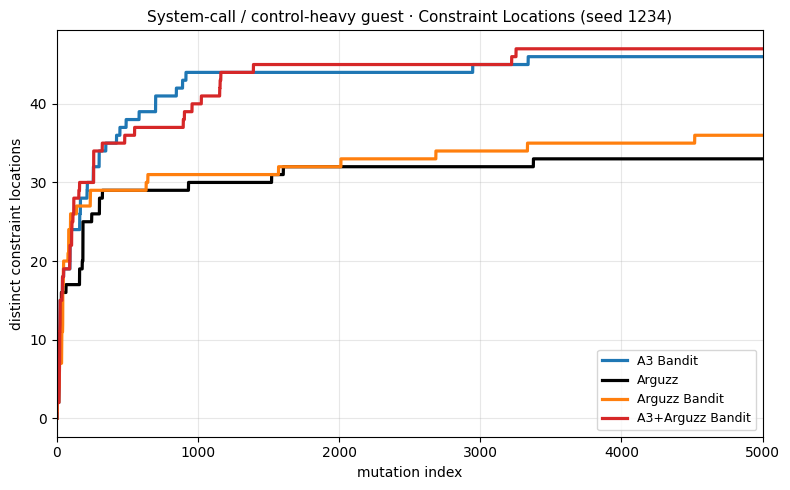

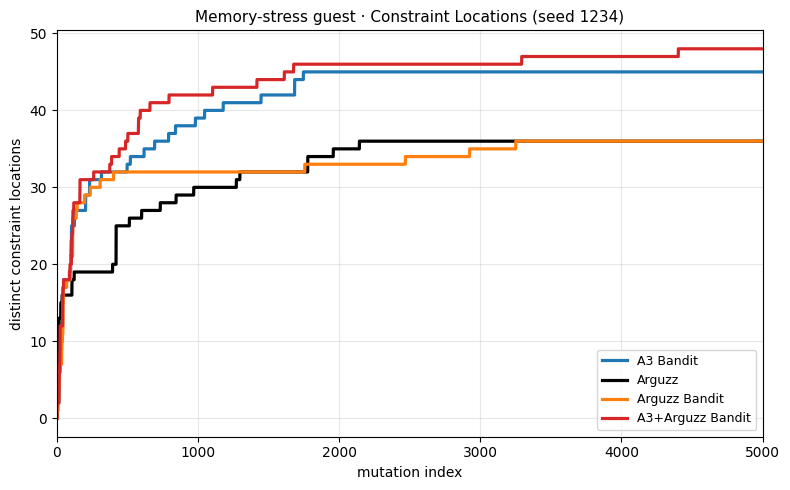

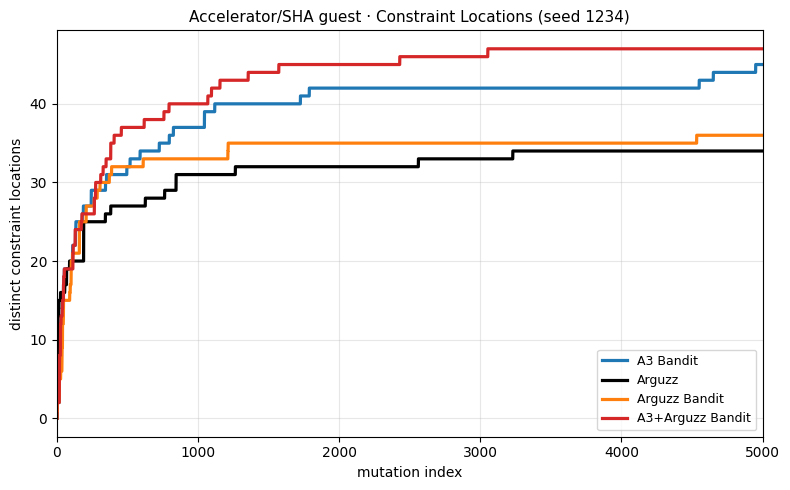

In [4]:
SEED = "1234"
for g, _ in GUESTS:
    fig, ax = plt.subplots(figsize=(8, 5))
    for v in VARIANTS:
        ids = points.get((g, v, SEED, "LOC"))
        if ids is None:
            continue
        ax.plot(np.arange(N + 1), cum(ids), color=COLORS[v], lw=2.3, label=DISPLAY[v])
    ax.set_title(f"{GUEST_TITLE[g]} · Constraint Locations (seed {SEED})", fontsize=11)
    ax.set_xlabel("mutation index"); ax.set_ylabel("distinct constraint locations")
    ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3); ax.margins(x=0)
    fig.tight_layout(); savepng(fig, f"curves_loc_{g}"); plt.show()

## Context territory / exclusivity tables
`total(exclusive)` per variant (seed 1234): total distinct contexts reached, and the subset reached by that
variant and **no other**. `common` = reached by all present variants; `union` = reached by any.

In [5]:
SEED = "1234"
def territory(g, mk):
    present = [v for v in VARIANTS if (g, v, SEED, mk) in KEYSETS]
    sets = {v: KEYSETS[(g, v, SEED, mk)] for v in present}
    common = set.intersection(*sets.values()) if sets else set()
    excl = {v: sets[v] - set().union(*[sets[o] for o in present if o != v]) for v in present}
    return present, sets, common, excl, (set().union(*sets.values()) if sets else set())
for mk, ml in METRICS:
    print(f"================  {ml}  ·  total(exclusive)  ·  seed {SEED}  ================")
    print(f"{'guest':<16}" + "".join(f"{DISPLAY[v][:13]:>15}" for v in VARIANTS) + f"{'common':>8}{'union':>7}")
    for g, _ in GUESTS:
        present, sets, common, excl, union = territory(g, mk)
        if not present:
            print(f"{g:<16}  (no data)"); continue
        cells = [f"{len(sets[v])}({len(excl[v])})" if v in present else "—" for v in VARIANTS]
        print(f"{g:<16}" + "".join(f"{c:>15}" for c in cells) + f"{len(common):>8}{len(union):>7}")
    print()

================  Constraint Locations  ·  total(exclusive)  ·  seed 1234  ================
guest                 A3 Bandit         Arguzz  Arguzz Bandit  A3+Arguzz Ban  common  union
g0_baseline               45(0)          33(0)          35(0)          49(2)      32     49
g1_ecall_control          46(0)          33(0)          36(0)          47(0)      32     48
g2_mem_stress             45(0)          36(0)          36(0)          48(0)      33     48
g3_accelerator            45(0)          34(0)          36(1)          47(1)      33     48

================  Local Contexts  ·  total(exclusive)  ·  seed 1234  ================
guest                 A3 Bandit         Arguzz  Arguzz Bandit  A3+Arguzz Ban  common  union
g0_baseline            651(100)         290(3)         289(1)        622(65)     256    738
g1_ecall_control       673(134)         291(5)         278(0)        603(50)     245    751
g2_mem_stress          659(145)         314(8)         297(0)        576(53)     260 

## Exclusive constraint-locations — full per-occurrence detail
Each constraint-location reached by **exactly one** variant (seed 1234), with **every** occurrence: the
mutation **index** it was hit at, its **major/minor**, the **mutation kind** that produced it, and whether the
verifier accepted (0 = the failure was caught, as expected on the clean binary). Source:
`data_extracted/exclusive_loc_detail.csv`.

In [6]:
import csv as _csv
det = list(_csv.DictReader(open(f"{BASE}/exclusive_loc_detail.csv"), delimiter="|"))
def parse_job(j):
    b = j
    v = next(x for x in ["V5_control", "V6_uniform", "V6_cTS", "Hybrid_cTS"] if f"_{x}_" in b)
    return b.split(f"_{v}_")[0], v, b.split("_seed")[1]
from collections import defaultdict
byloc = defaultdict(list)
for r in det:
    byloc[(r["job"], r["loc"])].append(r)
for (job, loc), occs in sorted(byloc.items()):
    g, v, s = parse_job(job)
    print(f"■ {loc}")
    print(f"    found by ONLY {DISPLAY[v]}  on  {GUEST_TITLE[g]}  (seed {s})   —   {len(occs)} occurrence(s)")
    print(f"      {'mut_index':>9} {'major':>6} {'minor':>6}  {'kind':<20} {'verifier_accepted':>17}")
    for r in sorted(occs, key=lambda x: int(x["mutation_index"])):
        print(f"      {r['mutation_index']:>9} {r['major']:>6} {r['minor']:>6}  {r['kind']:<20} {r['verifier_accepted']:>17}")
    print()

■ ControlMRET@inst_control.zir:93
    found by ONLY A3+Arguzz Bandit  on  Product-program mixed arithmetic  (seed 1234)   —   1 occurrence(s)
      mut_index  major  minor  kind                 verifier_accepted
            484      7      3  MEM_VAL_MOD                          0

■ ECallHostReadWords@inst_ecall.zir:171
    found by ONLY A3+Arguzz Bandit  on  Product-program mixed arithmetic  (seed 1234)   —   5 occurrence(s)
      mut_index  major  minor  kind                 verifier_accepted
            484      8      5  MEM_VAL_MOD                          0
           1000      8      5  MEM_VAL_MOD                          0
           1919      8      5  MEM_VAL_MOD                          0
           2317      8      5  MEM_VAL_MOD                          0
           3326      8      5  MEM_VAL_MOD                          0

■ ECallHostReadWords@inst_ecall.zir:171
    found by ONLY A3+Arguzz Bandit  on  Accelerator/SHA guest  (seed 1234)   —   2 occurrence(s)
      mut_i

## Territory bars — total vs exclusive (Local Context + CGC)
Per variant: **faded bar = total** contexts reached; **solid bar = exclusive** (only this variant). One figure
per guest; CTX (left) and CGC (right). Saved as `pngs/territory_ctxcgc_<guest>.png`.

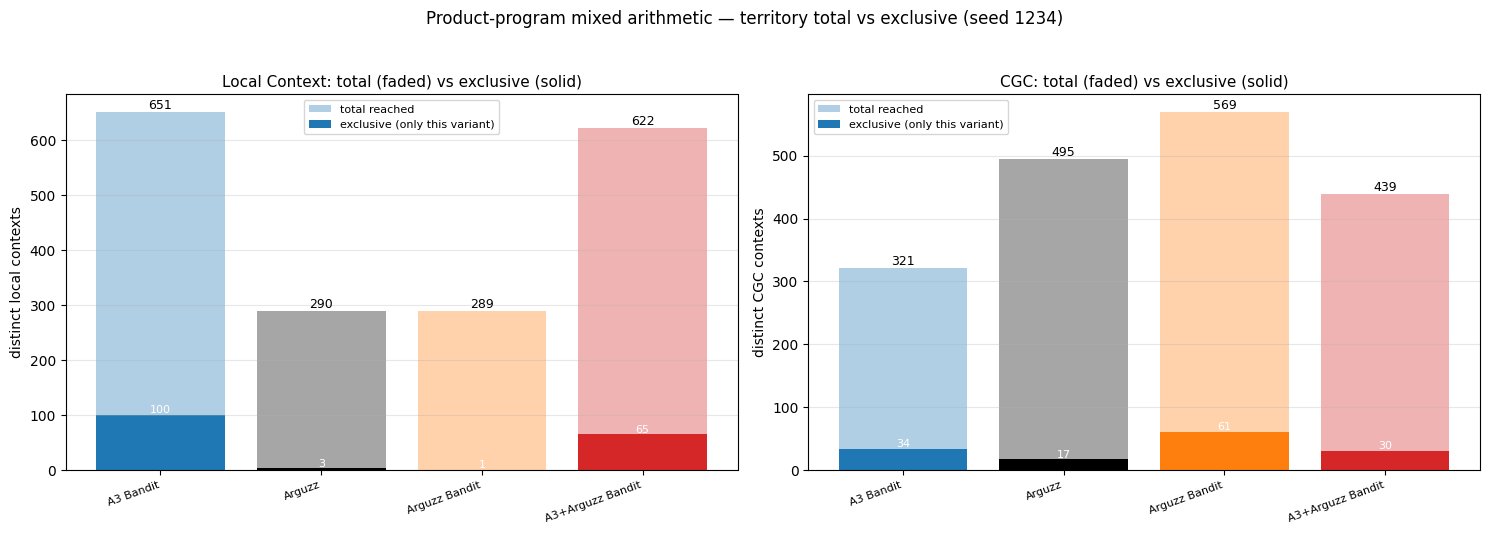

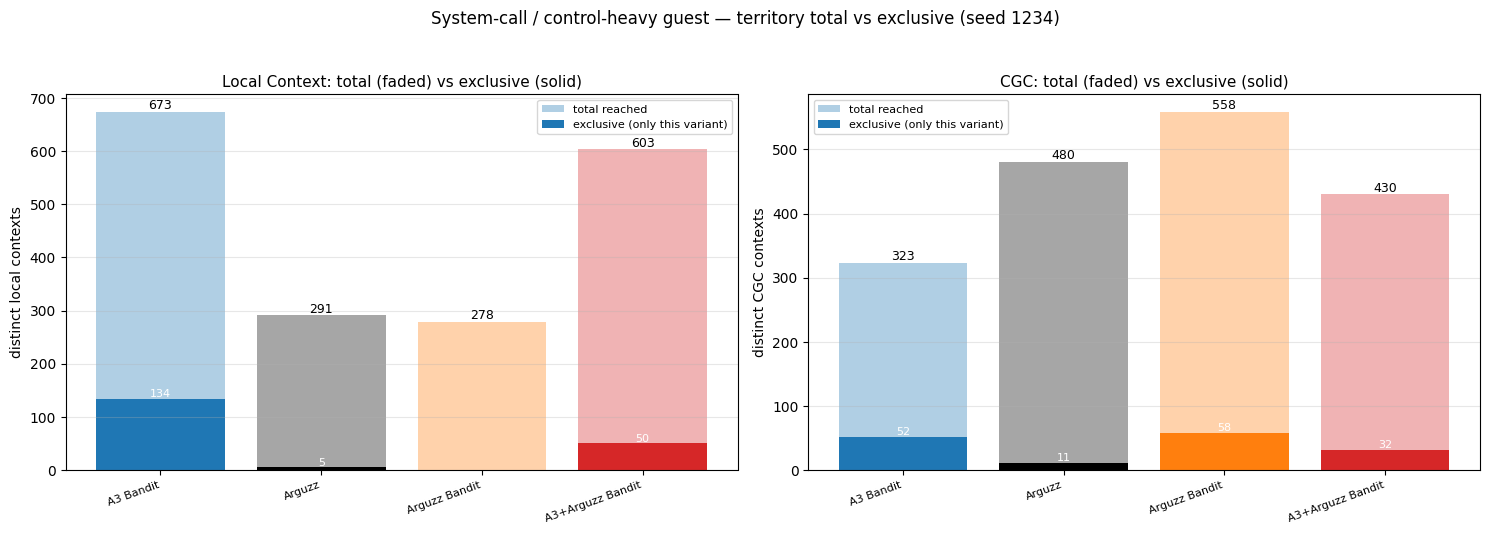

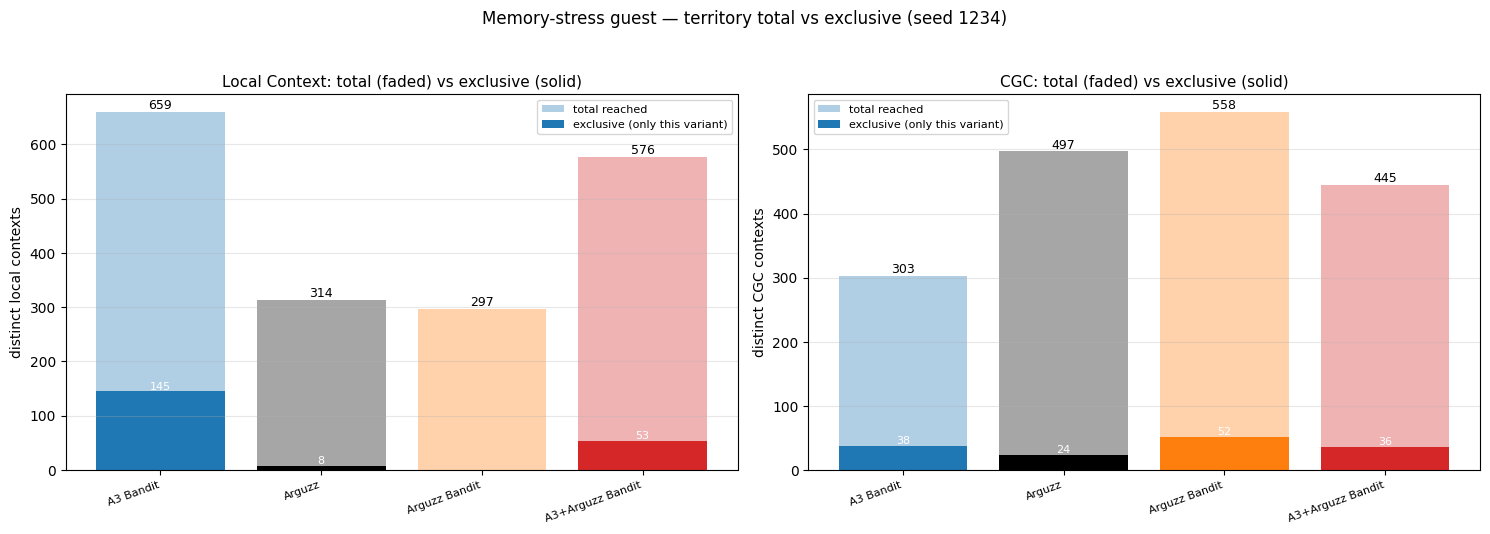

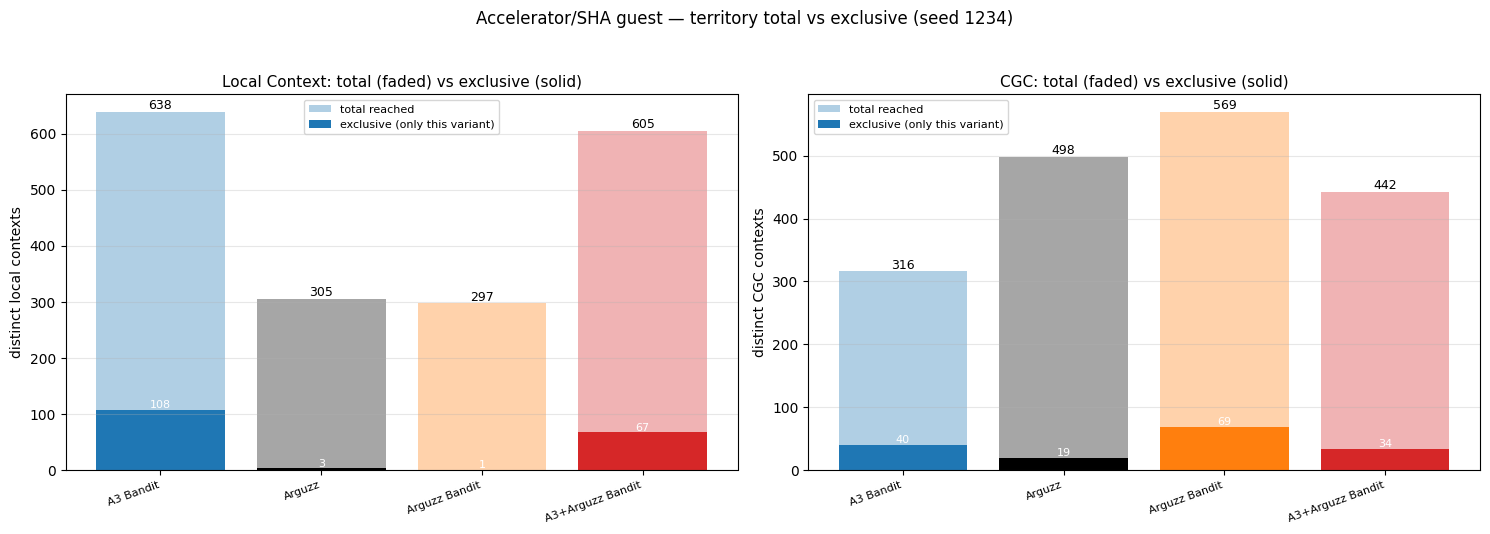

In [7]:
SEED = "1234"
def _tot_excl(g, mk):
    sets = {v: KEYSETS.get((g, v, SEED, mk), set()) for v in VARIANTS}
    totals = [len(sets[v]) for v in VARIANTS]
    excl = [len(sets[v] - set().union(*[sets[o] for o in VARIANTS if o != v])) for v in VARIANTS]
    return totals, excl
def _bars(ax, g, mk, ylab):
    totals, excl = _tot_excl(g, mk); xs = np.arange(len(VARIANTS))
    ax.bar(xs, totals, color=[COLORS[v] for v in VARIANTS], alpha=0.35, label="total reached")
    ax.bar(xs, excl, color=[COLORS[v] for v in VARIANTS], alpha=1.0, label="exclusive (only this variant)")
    for i, (t, e) in enumerate(zip(totals, excl)):
        ax.text(i, t, str(t), ha="center", va="bottom", fontsize=9)
        if e:
            ax.text(i, e, str(e), ha="center", va="bottom", fontsize=8, color="white")
    ax.set_xticks(xs); ax.set_xticklabels([DISPLAY[v] for v in VARIANTS], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(ylab); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
for g, _ in GUESTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
    _bars(axes[0], g, "CTX", "distinct local contexts"); axes[0].set_title("Local Context: total (faded) vs exclusive (solid)", fontsize=11)
    _bars(axes[1], g, "CGC", "distinct CGC contexts"); axes[1].set_title("CGC: total (faded) vs exclusive (solid)", fontsize=11)
    fig.suptitle(f"{GUEST_TITLE[g]} — territory total vs exclusive (seed {SEED})", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95]); savepng(fig, f"territory_ctxcgc_{g}"); plt.show()

## Territory bars — Constraint Locations (separate)
Same total-vs-exclusive view for LOC, on its own. Saved as `pngs/territory_loc_<guest>.png`.

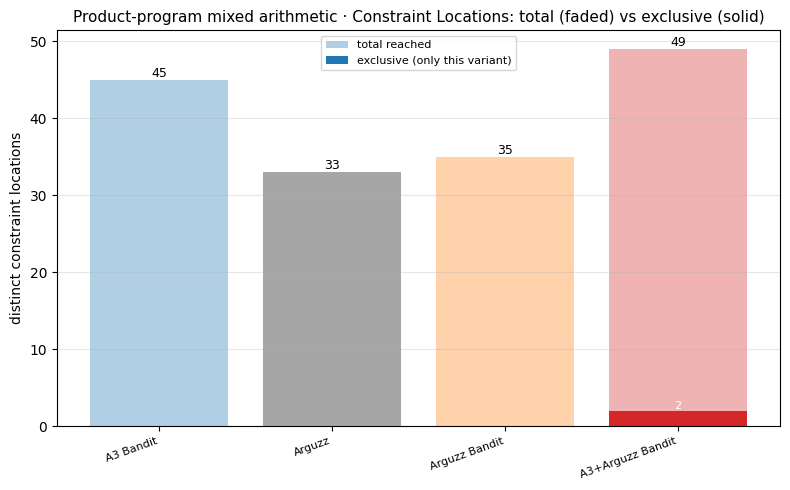

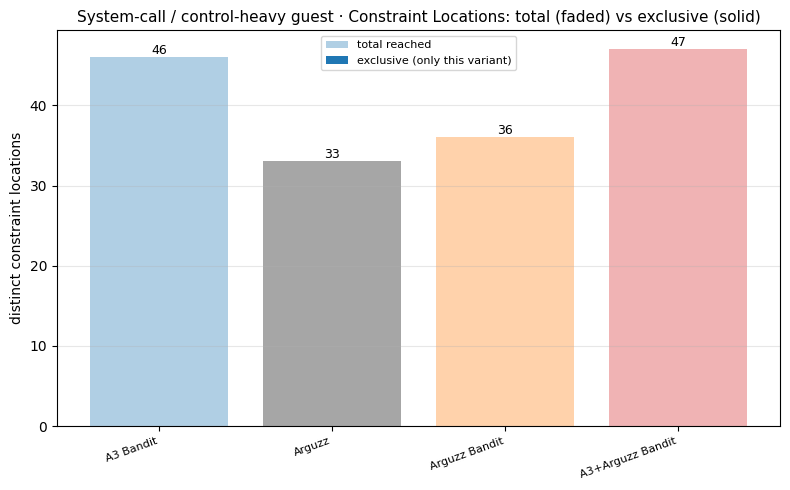

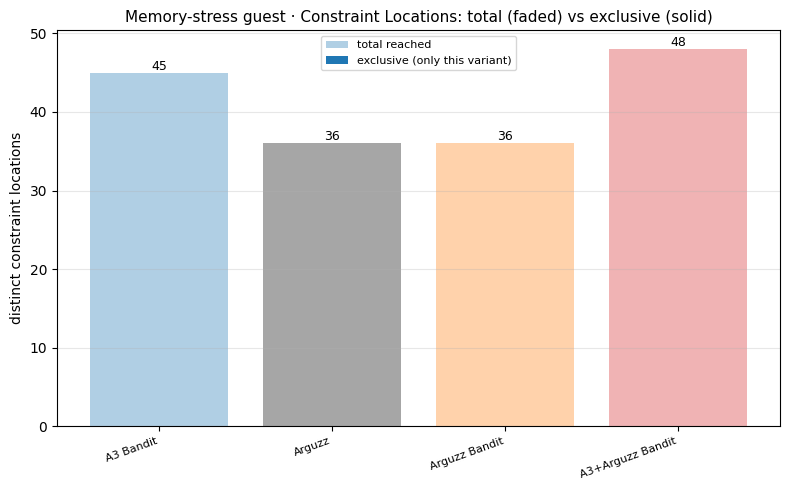

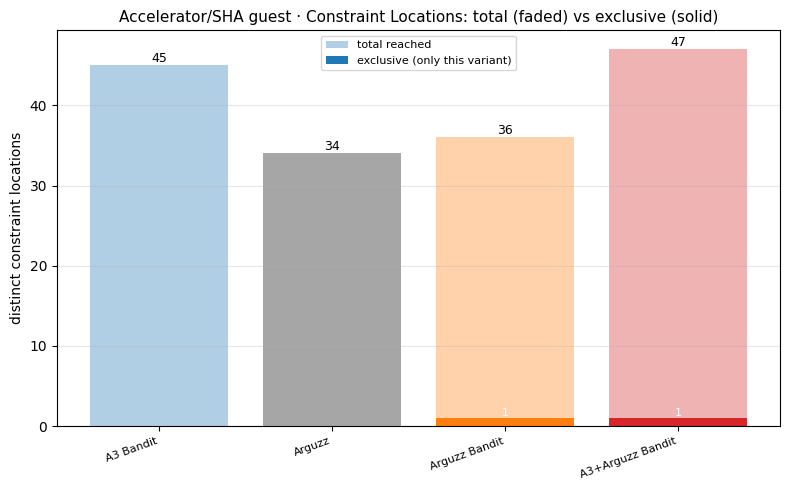

In [8]:
SEED = "1234"
for g, _ in GUESTS:
    fig, ax = plt.subplots(figsize=(8, 5))
    _bars(ax, g, "LOC", "distinct constraint locations")
    ax.set_title(f"{GUEST_TITLE[g]} · Constraint Locations: total (faded) vs exclusive (solid)", fontsize=11)
    fig.tight_layout(); savepng(fig, f"territory_loc_{g}"); plt.show()

## Territory composition — exclusive / shared-by-2 / -3 / common (Local Context + CGC)
Splits each variant's total into: exclusive, shared by exactly 2 / 3 variants, and common to all 4 — the
overlap structure the plain bars omit. Saved as `pngs/composition_ctxcgc_<guest>.png`.

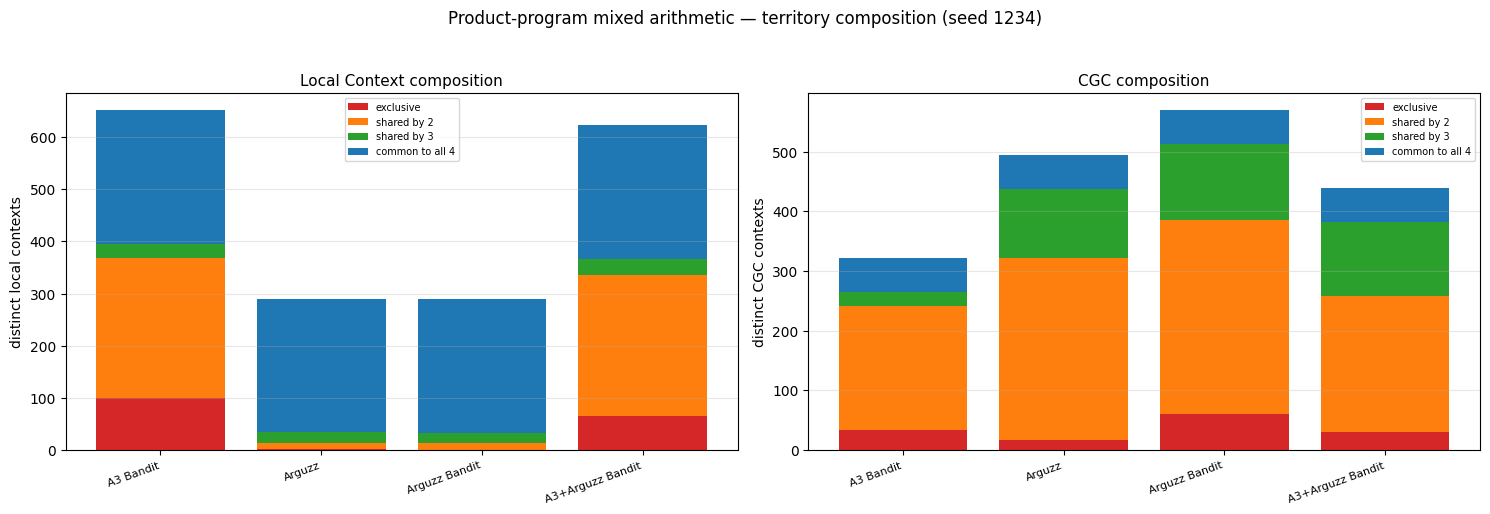

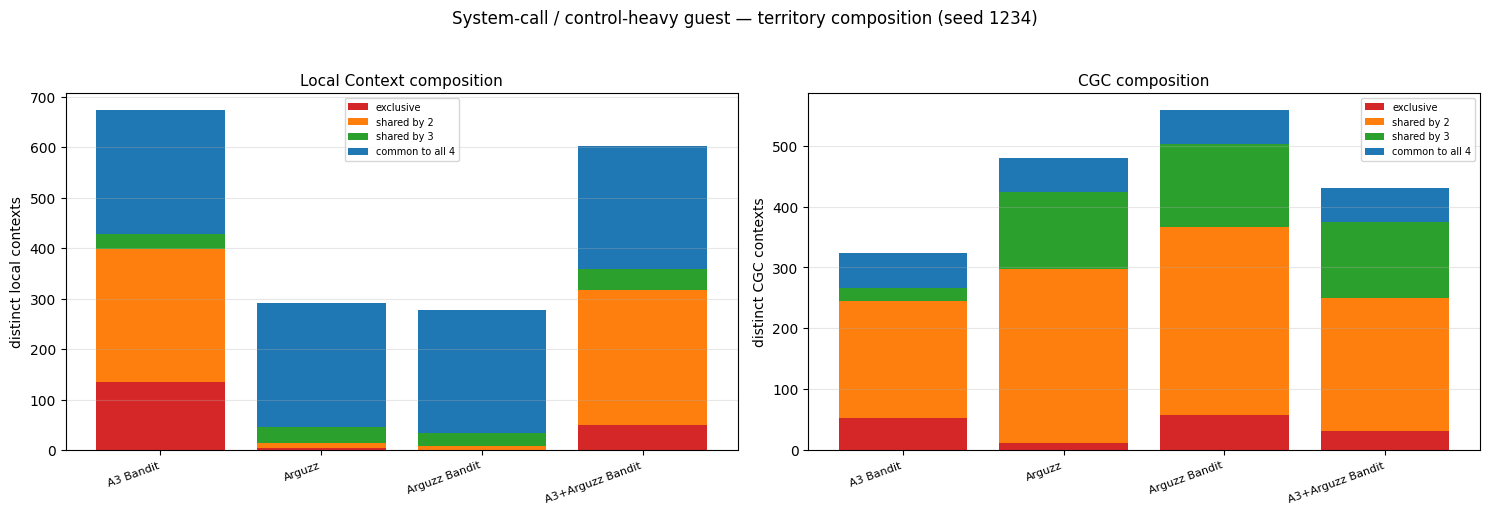

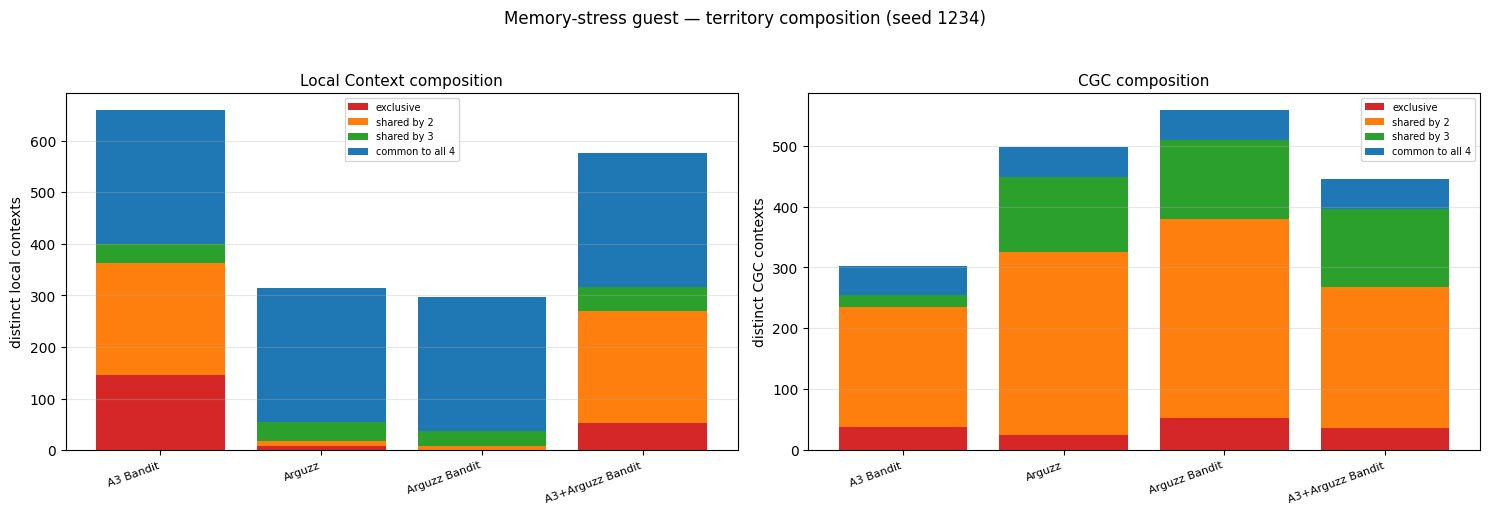

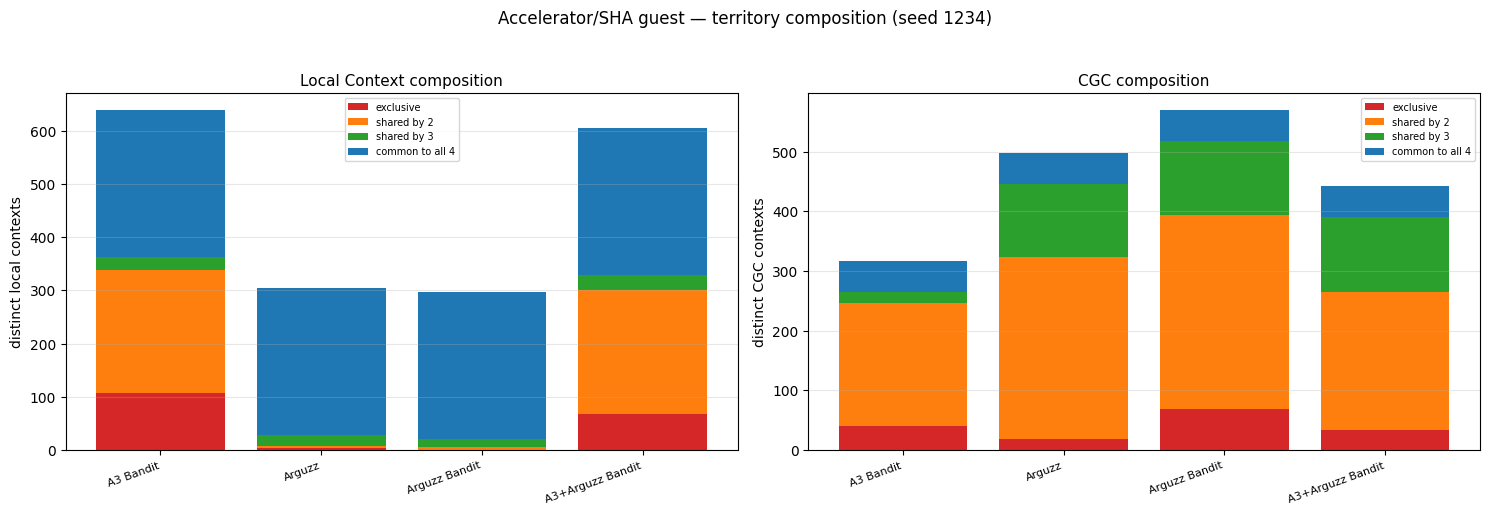

In [9]:
SEED = "1234"
shades = {1: "#d62728", 2: "#ff7f0e", 3: "#2ca02c", 4: "#1f77b4"}
labels = {1: "exclusive", 2: "shared by 2", 3: "shared by 3", 4: "common to all 4"}
def _comp(ax, g, mk, ylab):
    sets = {v: KEYSETS.get((g, v, SEED, mk), set()) for v in VARIANTS}
    allk = set().union(*sets.values()); owners = {k: sum(k in sets[v] for v in VARIANTS) for k in allk}
    xs = np.arange(len(VARIANTS)); bottoms = [0.0] * len(VARIANTS)
    for share in [1, 2, 3, 4]:
        vals = [sum(1 for k in sets[v] if owners[k] == share) for v in VARIANTS]
        ax.bar(xs, vals, bottom=bottoms, color=shades[share], label=labels[share])
        bottoms = [b + x for b, x in zip(bottoms, vals)]
    ax.set_xticks(xs); ax.set_xticklabels([DISPLAY[v] for v in VARIANTS], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(ylab); ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
for g, _ in GUESTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    _comp(axes[0], g, "CTX", "distinct local contexts"); axes[0].set_title("Local Context composition", fontsize=11)
    _comp(axes[1], g, "CGC", "distinct CGC contexts"); axes[1].set_title("CGC composition", fontsize=11)
    fig.suptitle(f"{GUEST_TITLE[g]} — territory composition (seed {SEED})", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95]); savepng(fig, f"composition_ctxcgc_{g}"); plt.show()

## Territory composition — Constraint Locations (separate)
Saved as `pngs/composition_loc_<guest>.png`.

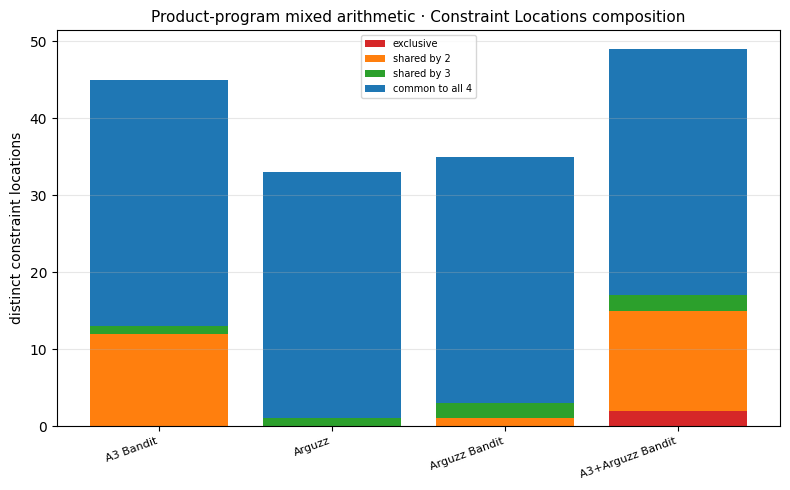

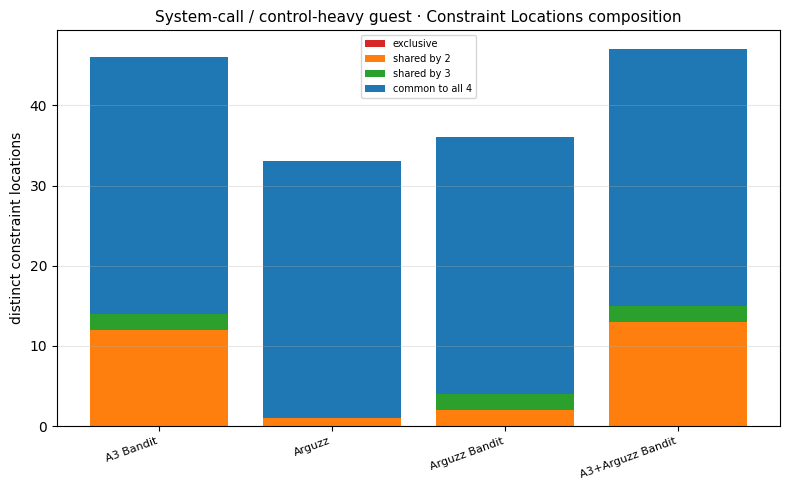

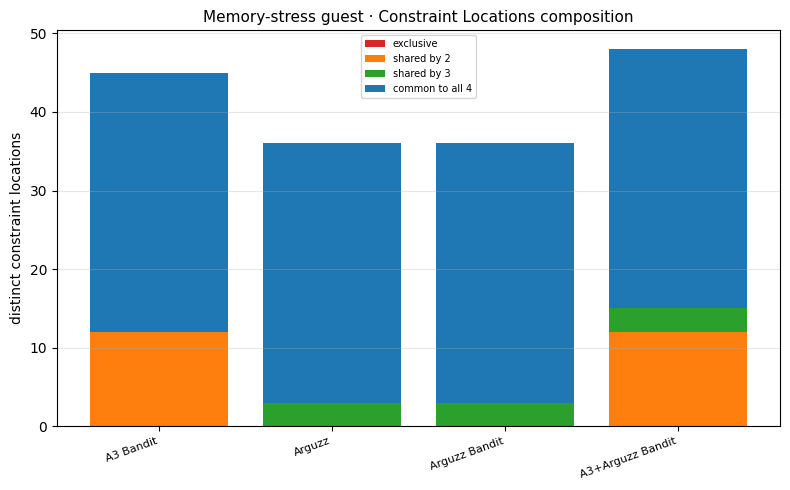

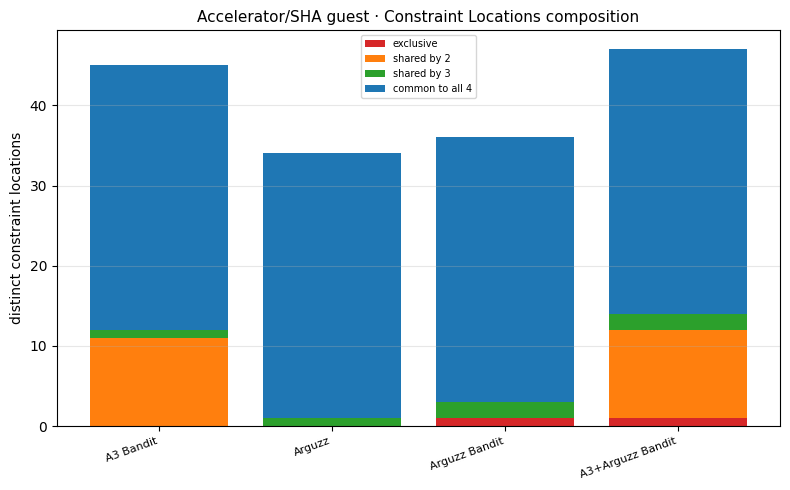

In [10]:
SEED = "1234"
for g, _ in GUESTS:
    fig, ax = plt.subplots(figsize=(8, 5))
    _comp(ax, g, "LOC", "distinct constraint locations")
    ax.set_title(f"{GUEST_TITLE[g]} · Constraint Locations composition", fontsize=11)
    fig.tight_layout(); savepng(fig, f"composition_loc_{g}"); plt.show()

## Failure-count distribution per mutation — "zero or many?"
Per applied mutation, # global constraint failures bucketed 0 / 1–10 / >10 (pooled over guests+seeds, final
campaign). Saved as `pngs/failure_distribution.png`.

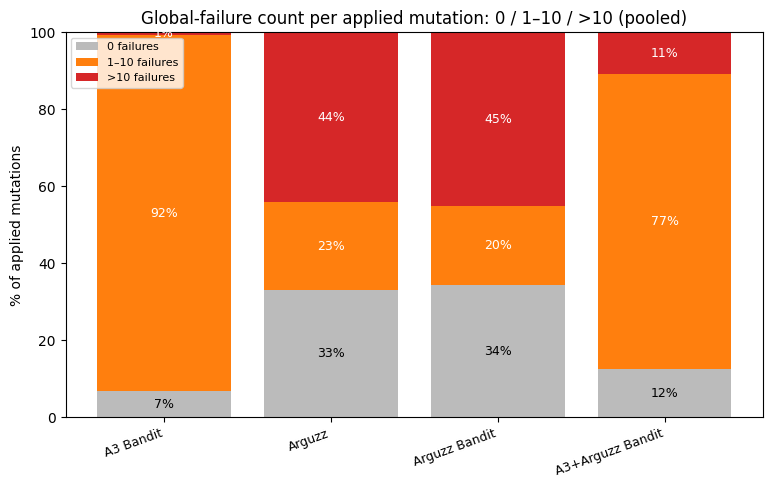

  A3 Bandit            0=  6.8%  1-10= 92.4%  >10=  0.9%  (n=59517)
  Arguzz               0= 33.0%  1-10= 23.0%  >10= 44.0%  (n=52168)
  Arguzz Bandit        0= 34.4%  1-10= 20.3%  >10= 45.3%  (n=56177)
  A3+Arguzz Bandit     0= 12.5%  1-10= 76.7%  >10= 10.8%  (n=58802)


In [11]:
import csv as _csv
from collections import defaultdict as _dd
gf = list(_csv.DictReader(open(f"{BASE}/gf_stats.csv"), delimiter="|"))
agg = _dd(lambda: [0, 0, 0, 0]); byg = _dd(lambda: [0, 0, 0, 0])
for r in gf:
    v = r['variant']
    for i, val in enumerate((int(r['n_applied']), int(r['n0']), int(r['n1_10']), int(r['ngt10']))):
        agg[v][i] += val; byg[(v, r['guest'])][i] += val
order = [v for v in VARIANTS if agg[v][0]]
fig, ax = plt.subplots(figsize=(9, 5)); xs = np.arange(len(order))
z  = [agg[v][1] / agg[v][0] * 100 for v in order]
m  = [agg[v][2] / agg[v][0] * 100 for v in order]
hi = [agg[v][3] / agg[v][0] * 100 for v in order]
ax.bar(xs, z, color="#bbbbbb", label="0 failures")
ax.bar(xs, m, bottom=z, color="#ff7f0e", label="1–10 failures")
ax.bar(xs, hi, bottom=[a + b for a, b in zip(z, m)], color="#d62728", label=">10 failures")
for i in range(len(order)):
    ax.text(i, z[i] / 2, f"{z[i]:.0f}%", ha="center", va="center", fontsize=9)
    ax.text(i, z[i] + m[i] / 2, f"{m[i]:.0f}%", ha="center", va="center", fontsize=9, color="white")
    ax.text(i, z[i] + m[i] + hi[i] / 2, f"{hi[i]:.0f}%", ha="center", va="center", fontsize=9, color="white")
ax.set_xticks(xs); ax.set_xticklabels([DISPLAY[v] for v in order], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% of applied mutations"); ax.set_ylim(0, 100)
ax.set_title("Global-failure count per applied mutation: 0 / 1–10 / >10 (pooled)"); ax.legend(fontsize=8)
savepng(fig, "failure_distribution"); plt.show()
for v in order:
    a, n0, n1, hh = agg[v]
    print(f"  {DISPLAY[v]:<20} 0={n0/a*100:5.1f}%  1-10={n1/a*100:5.1f}%  >10={hh/a*100:5.1f}%  (n={a})")

# ───────────────────────────────────────────────────────────────────────────
# STATISTICS — consolidated collection & review
All the requested statistics, recomputed here from the raw CSVs in one place, followed by self-checks.

**Methods (verified against the standalone source):**
- **Mean distinct CGC broken / mutation** — `record_compressed_global_first_hit()` is called once per
  **(mutation, distinct ctx_key)** in *every* recording path (`v6_uniform_driver.py`, `fuzzer.py`,
  `telemetry_v2.py`, each via `to_storage_rows(ctxs)` on a `Set`). Hence `SUM(hit_count)` over the final
  campaign = Σ over mutations of (#distinct contexts it broke); divide by #applied → the mean. Same dedup
  for Arguzz and A4, so it is apples-to-apples.
- **Failure-count distribution** — per applied mutation, COUNT(global_failures) bucketed 0 / 1–10 / >10.
- **Exclusive locs** — set-algebra on the final-campaign LOC keys (a loc reached by exactly one variant).
All numbers are final-campaign only (restart-decontaminated), pooled over guests+seeds.

In [12]:
import csv as _c
from collections import defaultdict as _dd
ORD = ["V6_uniform", "V6_cTS", "Hybrid_cTS", "V5_control"]

# ---- load the three stat CSVs ----
A = _dd(lambda: [0, 0, 0, 0])   # cgc_per_mut: sum_hit, n_applied, n_ctx, tot_gf
for r in _c.DictReader(open(f"{BASE}/cgc_per_mut.csv"), delimiter="|"):
    for i, k in enumerate(("sum_hit", "n_applied", "n_ctx", "tot_gf")):
        A[r["variant"]][i] += int(r[k])
B = _dd(lambda: [0, 0, 0, 0])   # gf_stats: n_applied, n0, n1_10, ngt10
for r in _c.DictReader(open(f"{BASE}/gf_stats.csv"), delimiter="|"):
    for i, k in enumerate(("n_applied", "n0", "n1_10", "ngt10")):
        B[r["variant"]][i] += int(r[k])
det = list(_c.DictReader(open(f"{BASE}/exclusive_loc_detail.csv"), delimiter="|"))

print("="*78)
print("STAT 1 — mean DISTINCT compressed-global contexts broken per APPLIED mutation")
print("="*78)
print(f"  {'variant':<22}{'mean CGC/mut':>13}{'mean raw gfail/mut':>20}{'compression':>13}")
for v in ORD:
    sh, na, nc, tg = A[v]
    print(f"  {DISPLAY[v]:<22}{sh/na:>13.2f}{tg/na:>20.2f}{tg/sh:>11.1f}x")
print(f"\n  >>> ANSWER:  Arguzz = {A['V6_uniform'][0]/A['V6_uniform'][1]:.2f}   vs   "
      f"A4 (V5) = {A['V5_control'][0]/A['V5_control'][1]:.2f}   (Arguzz breaks "
      f"{(A['V6_uniform'][0]/A['V6_uniform'][1])/(A['V5_control'][0]/A['V5_control'][1]):.1f}x more)")

print("\n" + "="*78)
print("STAT 2 — global-failure-count distribution per applied mutation (0 / 1-10 / >10)")
print("="*78)
for v in ORD:
    a, n0, n1, ng = B[v]
    print(f"  {DISPLAY[v]:<22} 0={n0/a*100:5.1f}%   1-10={n1/a*100:5.1f}%   >10={ng/a*100:5.1f}%   (n_applied={a})")

print("\n" + "="*78)
print("STAT 3 — exclusive constraint-locations (seed 1234) and occurrence counts")
print("="*78)
exloc = _dd(list)
for r in det:
    exloc[(r["job"], r["loc"])].append(r)
for (job, loc), occ in sorted(exloc.items()):
    vv = next(x for x in ORD if f"_{x}_" in job); gg = job.split(f"_{vv}_")[0]
    print(f"  {loc:<42} only {DISPLAY[vv]:<18} on {GUEST_TITLE[gg][:28]:<28} x{len(occ)}")

STAT 1 — mean DISTINCT compressed-global contexts broken per APPLIED mutation
  variant                mean CGC/mut  mean raw gfail/mut  compression
  Arguzz                         3.33                7.39        2.2x
  Arguzz Bandit                  7.19                7.33        1.0x
  A3+Arguzz Bandit               2.97                3.58        1.2x
  A3 Bandit                      1.66                2.33        1.4x

  >>> ANSWER:  Arguzz = 3.33   vs   A4 (V5) = 1.66   (Arguzz breaks 2.0x more)

STAT 2 — global-failure-count distribution per applied mutation (0 / 1-10 / >10)
  Arguzz                 0= 33.0%   1-10= 23.0%   >10= 44.0%   (n_applied=52168)
  Arguzz Bandit          0= 34.4%   1-10= 20.3%   >10= 45.3%   (n_applied=56177)
  A3+Arguzz Bandit       0= 12.5%   1-10= 76.7%   >10= 10.8%   (n_applied=58802)
  A3 Bandit              0=  6.8%   1-10= 92.4%   >10=  0.9%   (n_applied=59517)

STAT 3 — exclusive constraint-locations (seed 1234) and occurrence counts
  ControlM

### Review / self-checks (no statistic is reported without passing these)

In [13]:
ORD = ["V6_uniform", "V6_cTS", "Hybrid_cTS", "V5_control"]
allok = True
print("CHECK 1 — compression cannot increase the count: sum_hit (distinct) <= raw global_failures")
for v in ORD:
    sh, na, nc, tg = A[v]; ok = sh <= tg; allok &= ok
    print(f"   [{'PASS' if ok else 'FAIL'}] {DISPLAY[v]:<22} sum_hit={sh:<8} <= raw_gfail={tg}")

print("\nCHECK 2 — the two independent extractions agree on the denominator (#applied, final campaign)")
for v in ORD:
    ok = A[v][1] == B[v][0]; allok &= ok
    print(f"   [{'PASS' if ok else 'FAIL'}] {DISPLAY[v]:<22} cgc_per_mut n_applied={A[v][1]}  ==  gf_stats n_applied={B[v][0]}")

print("\nCHECK 3 — every distinct ctx is hit >=1x: n_ctx (coverage) <= sum_hit")
for v in ORD:
    sh, na, nc, tg = A[v]; ok = nc <= sh; allok &= ok
    print(f"   [{'PASS' if ok else 'FAIL'}] {DISPLAY[v]:<22} n_ctx={nc:<7} <= sum_hit={sh}")

print("\nCHECK 4 — unconditional vs conditional mean (conditional excludes the zero-breakers, via gf_stats n0)")
for v in ORD:
    sh, na, nc, tg = A[v]; a, n0, n1, ng = B[v]; nz = na - n0
    print(f"   {DISPLAY[v]:<22} unconditional={sh/na:.2f}   conditional(>=1 break)={sh/nz:.2f}   zero-frac={n0/na*100:.0f}%")

print("\n" + ("ALL CHECKS PASS ✓" if allok else "*** A CHECK FAILED — DO NOT TRUST THE NUMBERS ***"))

CHECK 1 — compression cannot increase the count: sum_hit (distinct) <= raw global_failures
   [PASS] Arguzz                 sum_hit=173759   <= raw_gfail=385482
   [PASS] Arguzz Bandit          sum_hit=403840   <= raw_gfail=411721
   [PASS] A3+Arguzz Bandit       sum_hit=174776   <= raw_gfail=210618
   [PASS] A3 Bandit              sum_hit=98990    <= raw_gfail=138900

CHECK 2 — the two independent extractions agree on the denominator (#applied, final campaign)
   [PASS] Arguzz                 cgc_per_mut n_applied=52168  ==  gf_stats n_applied=52168
   [PASS] Arguzz Bandit          cgc_per_mut n_applied=56177  ==  gf_stats n_applied=56177
   [PASS] A3+Arguzz Bandit       cgc_per_mut n_applied=58802  ==  gf_stats n_applied=58802
   [PASS] A3 Bandit              cgc_per_mut n_applied=59517  ==  gf_stats n_applied=59517

CHECK 3 — every distinct ctx is hit >=1x: n_ctx (coverage) <= sum_hit
   [PASS] Arguzz                 n_ctx=5446    <= sum_hit=173759
   [PASS] Arguzz Bandit          n